# Análise Exploratória — Base de Modelagem (Alunos + Infraestrutura)

O objetivo aqui não é só descrever os dados, é usar essa exploração pra fundamentar as decisões que vou tomar na etapa de modelagem (quais features usar, como tratar nulos, qual métrica de avaliação faz sentido). Uso a base já validada no Dia 1 (sem `proficiencia`, que é leakage direto do alvo).

In [2]:
import sys
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.load_data import obter_base_modelagem

sns.set_style("whitegrid")

# forcar_releitura=True porque mudei o load_data.py nesta etapa (agora
# traz metas, território completo e evolução temporal, que faltavam) -
# o cache antigo tinha o schema anterior, mais simples
base = obter_base_modelagem(forcar_releitura=True)

# proficiencia é leakage confirmado no Dia 1 - tiro ela daqui já de cara
# pra não correr o risco de usar sem querer em algum gráfico
base = base.drop(columns=["proficiencia"])

base.shape

alunos: 3,867,999 linhas, 20 colunas
infraestrutura por município: 10,466 linhas, 19 colunas
metas por município: 10,704 linhas, 17 colunas
  removendo por risco de leakage por agregação: ['taxa_alfabetizacao', 'nivel_alfabetizacao']
  removendo por ser redundante/colidir com a rede do aluno: ['rede']
evolução temporal (município): 10,466 linhas
município completo: 23,995 linhas, 42 colunas totais
  removendo por risco de leakage por agregação: ['taxa_alfabetizacao', 'media_portugues', 'proporcao_aluno_nivel_0', 'proporcao_aluno_nivel_1', 'proporcao_aluno_nivel_2', 'proporcao_aluno_nivel_3', 'proporcao_aluno_nivel_4', 'proporcao_aluno_nivel_5', 'proporcao_aluno_nivel_6', 'proporcao_aluno_nivel_7', 'proporcao_aluno_nivel_8']
  colunas mantidas (31): ['ano', 'id_municipio', 'serie', 'rede', 'rede_descricao', 'id_municipio_6', 'id_municipio_tse', 'id_municipio_rf', 'id_municipio_bcb', 'nome', 'capital_uf', 'id_comarca', 'id_regiao_saude', 'nome_regiao_saude', 'id_regiao_imediata', 'nome_r

(3867999, 65)

## 1. Visão geral da base

In [3]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 65 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   ano                                  Int64  
 1   id_municipio                         str    
 2   id_escola                            str    
 3   id_aluno                             str    
 4   caderno                              str    
 5   serie                                str    
 6   rede                                 str    
 7   presenca                             str    
 8   preenchimento_caderno                str    
 9   alfabetizado                         str    
 10  peso_aluno                           float64
 11  rede_descricao                       str    
 12  alfabetizado_descricao               str    
 13  presenca_descricao                   str    
 14  preenchimento_caderno_descricao      str    
 15  nome_x                               str   

In [4]:
# percentual de nulos por coluna - ordenado do maior pro menor, pra eu ver
# rápido onde vou precisar de imputação na etapa de pipeline
percentual_nulos = (base.isnull().mean() * 100).sort_values(ascending=False)
percentual_nulos[percentual_nulos > 0]

taxa_alfabetizacao_ano_anterior        51.121239
variacao_pp                            51.121239
id_regiao_metropolitana                46.709836
nome_regiao_metropolitana              46.709836
peso_aluno                             13.271410
meta_alfabetizacao_2024                 5.323967
percentual_participacao                 4.458636
sigla_uf_y                              3.948398
meta_alfabetizacao_2028                 3.948398
meta_alfabetizacao_2027                 3.948398
nome_y                                  3.948398
nome_uf_y                               3.948398
nome_regiao_y                           3.948398
meta_alfabetizacao_2029                 3.948398
meta_alfabetizacao_2030                 3.948398
meta_alfabetizacao_2026                 3.948398
meta_alfabetizacao_2025                 3.948398
nome_mesorregiao                        0.108557
id_municipio_6                          0.108557
id_regiao_saude                         0.108557
id_comarca          

## 2. Distribuição do target (`alfabetizado`)

Preciso saber se as classes estão balanceadas antes de escolher a métrica de avaliação lá na frente (acurácia só funciona bem se as classes forem parecidas em tamanho).

alfabetizado
1    1984546
0    1883453
Name: count, dtype: int64

alfabetizado
1    51.31
0    48.69
Name: proportion, dtype: float64


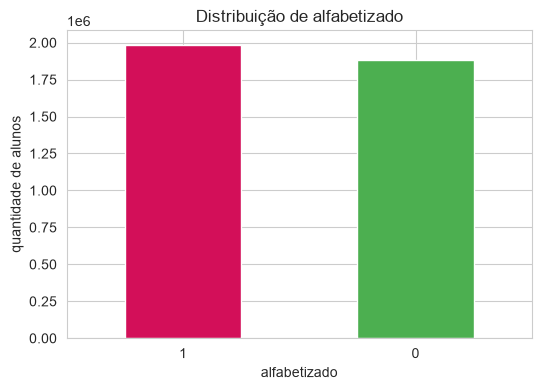

In [5]:
contagem_target = base["alfabetizado"].value_counts()
proporcao_target = base["alfabetizado"].value_counts(normalize=True) * 100

print(contagem_target)
print()
print(proporcao_target.round(2))

plt.figure(figsize=(6, 4))
contagem_target.plot(kind="bar", color=["#D30F59", "#4CAF50"])
plt.title("Distribuição de alfabetizado")
plt.xlabel("alfabetizado")
plt.ylabel("quantidade de alunos")
plt.xticks(rotation=0)
plt.show()

*(anotar aqui depois de rodar: as classes estão balanceadas ou não? isso já indica se preciso pensar em F1/AUC em vez de acurácia)*

## 3. Variáveis numéricas: distribuição por classe do target

As colunas de infraestrutura escolar são percentuais (0 a 100). Quero ver se elas se comportam diferente entre alunos alfabetizados e não alfabetizados.

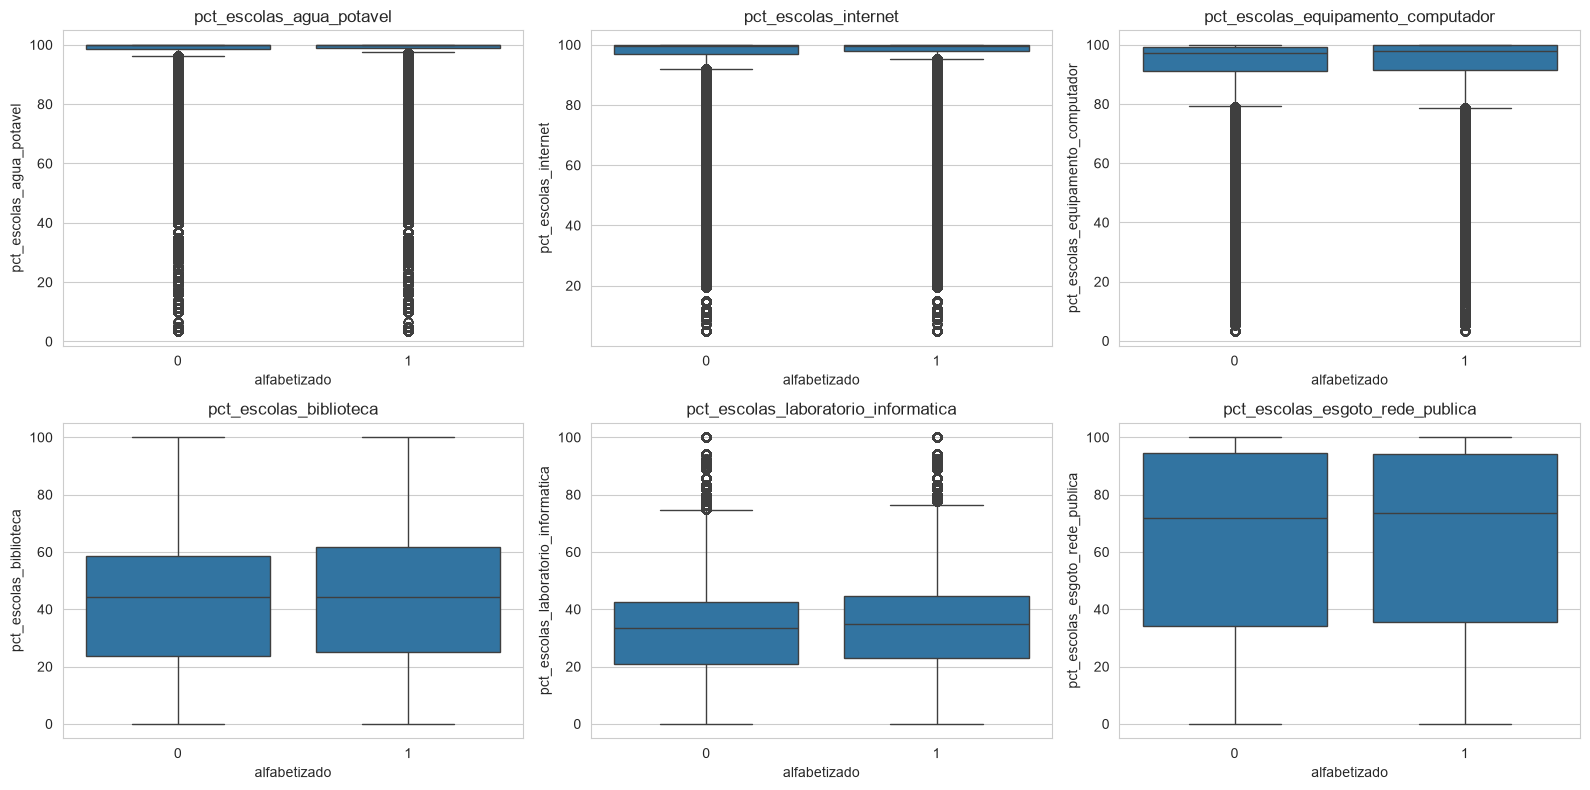

In [6]:
colunas_infraestrutura = [
    "pct_escolas_agua_potavel",
    "pct_escolas_internet",
    "pct_escolas_equipamento_computador",
    "pct_escolas_biblioteca",
    "pct_escolas_laboratorio_informatica",
    "pct_escolas_esgoto_rede_publica",
]

fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
eixos = eixos.flatten()

for i, coluna in enumerate(colunas_infraestrutura):
    sns.boxplot(data=base, x="alfabetizado", y=coluna, ax=eixos[i])
    eixos[i].set_title(coluna)

plt.tight_layout()
plt.show()

*(anotar aqui: alguma dessas variáveis mostra diferença visível entre as classes? isso sustenta a hipótese de infraestrutura como fator relevante)*

## 4. Variáveis categóricas: proporção de alfabetização por categoria

Testando a hipótese de que a rede de ensino e a região têm relação com a taxa de alfabetização.

Taxa de alfabetização por rede de ensino (%):
rede_descricao
Privada      64.00
Estadual     53.15
Municipal    51.07
Name: alfabetizado, dtype: float64


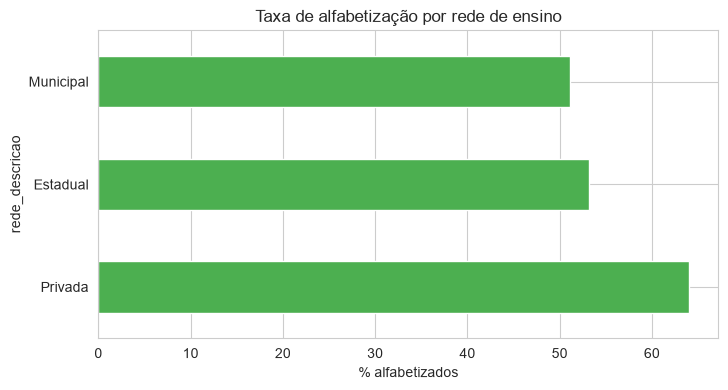

In [7]:
# taxa de alfabetização por rede de ensino (usando a coluna já traduzida)
taxa_por_rede = base.groupby("rede_descricao")["alfabetizado"].apply(
    lambda serie: (serie.astype(int) == 1).mean() * 100
).sort_values(ascending=False)

print("Taxa de alfabetização por rede de ensino (%):")
print(taxa_por_rede.round(2))

taxa_por_rede.plot(kind="barh", figsize=(8, 4), color="#4CAF50")
plt.xlabel("% alfabetizados")
plt.title("Taxa de alfabetização por rede de ensino")
plt.show()

Taxa de alfabetização por região (%):
nome_regiao
Centro-Oeste    54.71
Sudeste         53.57
Sul             52.79
Nordeste        50.65
Norte           41.77
Name: alfabetizado, dtype: float64


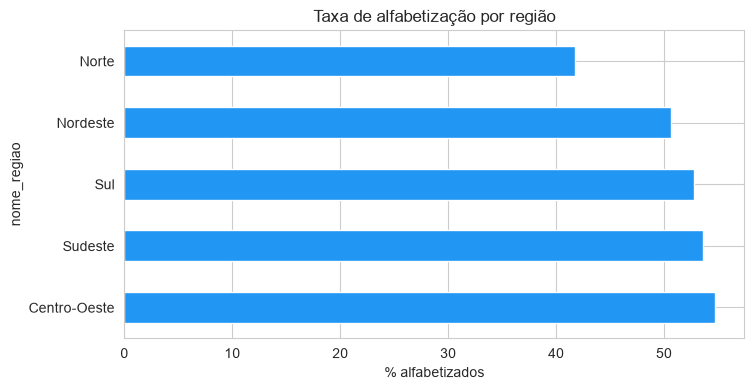

In [8]:
# taxa de alfabetização por região
taxa_por_regiao = base.groupby("nome_regiao")["alfabetizado"].apply(
    lambda serie: (serie.astype(int) == 1).mean() * 100
).sort_values(ascending=False)

print("Taxa de alfabetização por região (%):")
print(taxa_por_regiao.round(2))

taxa_por_regiao.plot(kind="barh", figsize=(8, 4), color="#2196F3")
plt.xlabel("% alfabetizados")
plt.title("Taxa de alfabetização por região")
plt.show()

*(anotar aqui: existe diferença relevante entre redes/regiões? qual a maior e a menor taxa?)*

## 5. Ano (2023 vs 2024): o padrão muda?

O handoff registra uma mudança de metodologia da fonte entre 2023 e 2024 em algumas colunas - quero ver se isso afeta a taxa de alfabetização observada.

In [9]:
taxa_por_ano = base.groupby("ano")["alfabetizado"].apply(
    lambda serie: (serie.astype(int) == 1).mean() * 100
)
print(taxa_por_ano.round(2))

ano
2023    50.21
2024    52.21
Name: alfabetizado, dtype: float64


*(anotar aqui: a taxa mudou muito de um ano pro outro? isso pode indicar que `ano` é uma feature relevante, ou que preciso ter cuidado ao combinar os dois anos)*

## 6. Matriz de correlação entre as variáveis numéricas

Só entre as colunas de infraestrutura (as únicas numéricas contínuas que sobraram depois de tirar `proficiencia`) - quero ver se tem multicolinearidade forte entre elas, o que pode ser um problema pra alguns modelos lineares.

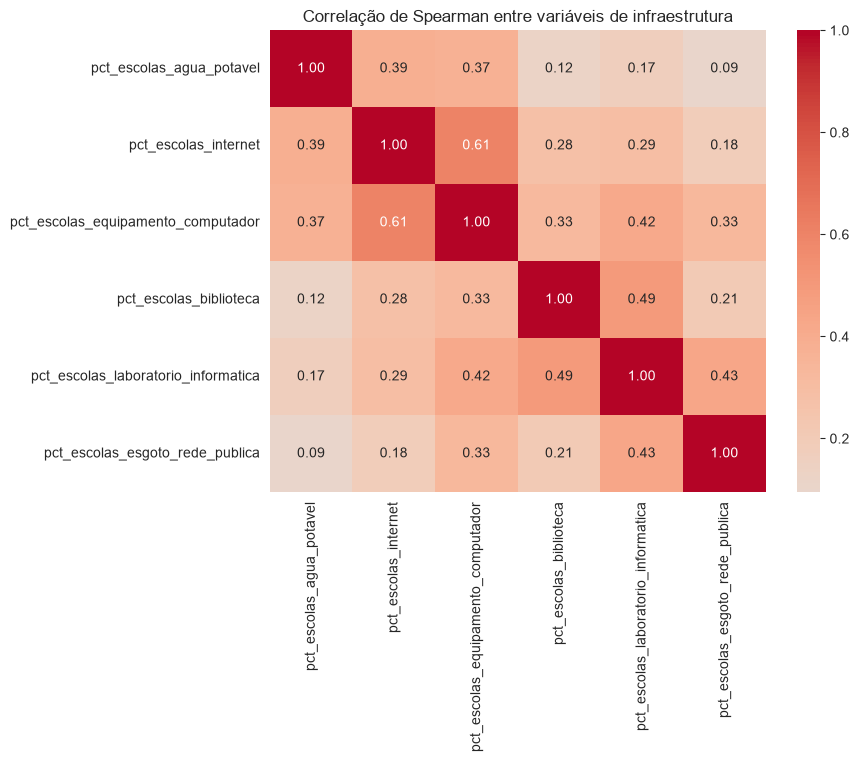

In [10]:
matriz_correlacao = base[colunas_infraestrutura].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação de Spearman entre variáveis de infraestrutura")
plt.show()

*(anotar aqui: alguma dupla de variáveis está fortemente correlacionada? isso é um ponto a considerar na feature selection do Dia 3)*

Correlação de Spearman de cada coluna com `alfabetizado` (ordenado por força, sem olhar o sinal):
preenchimento_caderno_bin              0.402
presenca_bin                           0.401
taxa_alfabetizacao_ano_anterior        0.225
variacao_pp                            0.108
pct_escolas_agua_potavel               0.091
pct_escolas_internet                   0.088
pct_escolas_equipamento_computador     0.077
regiao_Norte                          -0.069
pct_escolas_laboratorio_informatica    0.067
pct_escolas_biblioteca                 0.042
regiao_Sudeste                         0.032
regiao_Centro-Oeste                    0.022
ano                                    0.020
regiao_Sul                             0.014
pct_escolas_esgoto_rede_publica        0.013
rede_Municipal                        -0.013
rede_Estadual                          0.013
regiao_Nordeste                       -0.008
rede_Privada                           0.001
serie                                    NaN
Na

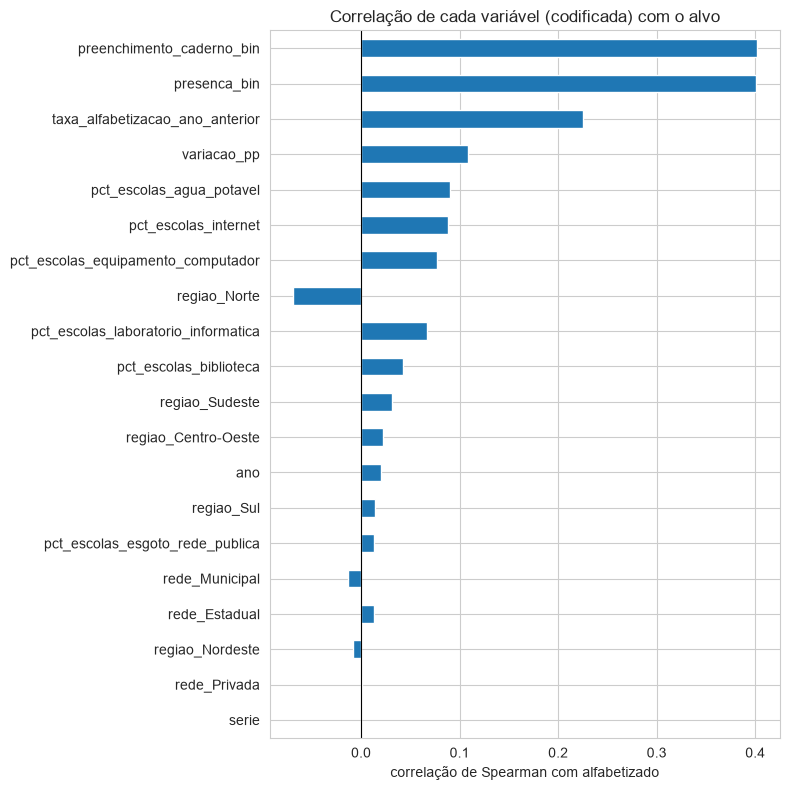

In [11]:
# pedido extra: em vez de só olhar a correlação entre as colunas de
# infraestrutura entre si, quero uma tabela única com a correlação de
# CADA coluna (numérica ou categórica, codificada) com o próprio alvo
# `alfabetizado` - complementa a importância de árvore da Seção 8 com uma
# visão de correlação simples (rank/Spearman), mais fácil de interpretar
# feature a feature.

colunas_numericas_para_correlacao = colunas_infraestrutura + [
    "taxa_alfabetizacao_ano_anterior",
    "variacao_pp",
    "serie",
    "ano",
]
colunas_numericas_para_correlacao = [c for c in colunas_numericas_para_correlacao if c in base.columns]

base_correlacao = base[colunas_numericas_para_correlacao].copy()

# presenca/preenchimento_caderno já são essencialmente binárias (Seção 9.1) -
# codifico como 0/1 (1 = presente/preenchida) pra poder entrar na correlação
base_correlacao["presenca_bin"] = (base["presenca_descricao"] == "Presente").astype(int)
base_correlacao["preenchimento_caderno_bin"] = (
    base["preenchimento_caderno_descricao"] == "Prova preenchida"
).astype(int)

# rede e região são nominais (sem ordem) - uma dummy por categoria, cada
# uma entra como sua própria "coluna" na tabela de correlação
dummies_rede = pd.get_dummies(base["rede_descricao"], prefix="rede")
dummies_regiao_corr = pd.get_dummies(base["nome_regiao"], prefix="regiao")
base_correlacao = pd.concat([base_correlacao, dummies_rede, dummies_regiao_corr], axis=1)

base_correlacao["alfabetizado"] = base["alfabetizado"].astype(int)

correlacao_com_alvo = (
    base_correlacao.corr(method="spearman")["alfabetizado"]
    .drop("alfabetizado")
    .sort_values(key=abs, ascending=False)
)

print("Correlação de Spearman de cada coluna com `alfabetizado` (ordenado por força, sem olhar o sinal):")
print(correlacao_com_alvo.round(3))

plt.figure(figsize=(8, 8))
correlacao_com_alvo.plot(kind="barh")
plt.xlabel("correlação de Spearman com alfabetizado")
plt.title("Correlação de cada variável (codificada) com o alvo")
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

*(anotar aqui depois de rodar: qual variável tem a correlação mais forte com o alvo nessa visão simples? Isso deve bater, em grande parte, com o que a Seção 8 (importância de árvore) já mostrou — `presenca_bin`/`preenchimento_caderno_bin` devem aparecer no topo (é o leakage estrutural aparecendo aqui também, de outra forma), seguidas de `taxa_alfabetizacao_ano_anterior`. Serve como checagem cruzada: se uma variável tem importância alta na árvore mas correlação simples baixa (ou vice-versa), pode indicar uma relação não-linear ou uma interação com outra variável, não captada por essa tabela.)*

**Sobre `preenchimento_caderno_bin` especificamente (ligado à dúvida sobre grão aluno + filtro de presentes):** essa coluna, no schema original (handoff, seção 8.3), é `string/código` — ou seja, é uma variável **categórica binária** (2 categorias: preenchida/não preenchida), não numérica contínua. Por isso codifiquei como 0/1 acima (`preenchimento_caderno_bin`) antes de calcular a correlação — é o jeito correto de tratar uma categórica binária numa matriz de correlação (equivalente ao coeficiente phi). Se eu decidir seguir com a opção de restringir o modelo a alunos **presentes** (opção (b) da pendência 1), a Seção 9.1 já mostrou que, dentro desse subconjunto, só sobram 1.185 casos de "não preenchida" contra 3.354.661 de "preenchida" — uma variável quase constante nesse recorte (99,96% numa única categoria). Nesse cenário, `preenchimento_caderno` teria variância baixíssima e, na prática, quase nenhum poder preditivo remanescente — não valeria a pena mantê-la como feature separada de `presenca` depois de aplicado o filtro.

## 7. Quantos municípios existem na base, e quantos alunos por município?

Isso é central pra decidir se faz sentido continuar tratando o problema como "previsão por aluno" ou se, na prática, a maior parte da informação que o modelo vai usar é herdada do município (o que tornaria a granularidade real do problema mais parecida com "por município" do que com "por aluno"). O Brasil tem 5.570 municípios - quero ver quantos aparecem de fato na base e quantos alunos cada um tem em média.

Municípios distintos na base: 5,548 (de 5.570 no Brasil)

Distribuição de alunos por município:
count      5548.000000
mean        697.187996
std        2796.578332
min          10.000000
25%         110.000000
50%         234.000000
75%         526.250000
max      107729.000000
dtype: float64


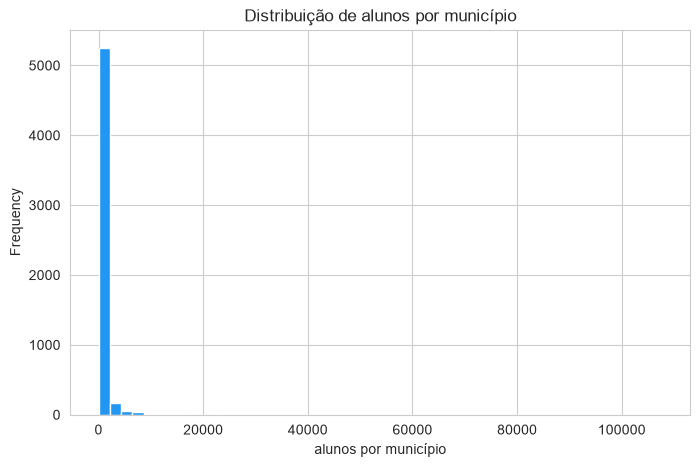

In [12]:
n_municipios = base["id_municipio"].nunique()
alunos_por_municipio = base.groupby("id_municipio").size()

print(f"Municípios distintos na base: {n_municipios:,} (de 5.570 no Brasil)")
print(f"\nDistribuição de alunos por município:")
print(alunos_por_municipio.describe())

plt.figure(figsize=(8, 5))
alunos_por_municipio.plot(kind="hist", bins=50, color="#2196F3")
plt.xlabel("alunos por município")
plt.title("Distribuição de alunos por município")
plt.show()

*(anotar aqui: qual a mediana de alunos por município? isso mostra quantas vezes, em média, o mesmo valor de infraestrutura/território/meta se repete na base)*

## 8. Diagnóstico: o quanto as features realmente variam no nível do aluno?

**Isso NÃO é o modelo final do Dia 4** - é um modelo diagnóstico rápido, só pra responder uma pergunta específica antes de fechar a estratégia de modelagem: as variáveis que mais pesam na predição são as que variam por aluno (`serie`, `rede`, `presenca`, `preenchimento_caderno`) ou as que são herdadas inteiras do município (infraestrutura, metas, território)?

Se o resultado mostrar que praticamente todo o peso preditivo vem de variáveis herdadas do município, isso é evidência de que, na prática, meu problema se comporta mais como "prever o risco do município" do que "prever o aluno individualmente" - preciso documentar isso e ajustar a estratégia de validação (Dia 3) de acordo, em vez de fingir que é uma predição individual genuína.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# uso uma amostra pra esse diagnóstico rodar rápido - não preciso da base
# inteira só pra comparar importância relativa dos grupos de variáveis
amostra = base.sample(n=300_000, random_state=42)

features_aluno = ["serie", "rede", "presenca", "preenchimento_caderno"]
features_municipio_base = [
    "pct_escolas_agua_potavel",
    "pct_escolas_internet",
    "pct_escolas_equipamento_computador",
    "pct_escolas_biblioteca",
    "pct_escolas_laboratorio_informatica",
    "pct_escolas_esgoto_rede_publica",
    "taxa_alfabetizacao_ano_anterior",
    "variacao_pp",
]
# uso só as colunas de meta/infraestrutura que sei que existem de antemão -
# se município_completo trouxe outras colunas numéricas úteis, dá pra
# adicionar aqui depois de ver o que apareceu no print do load_data.py
features_municipio_base = [c for c in features_municipio_base if c in amostra.columns]

# adicionando região aqui - na Seção 4 vi que existe diferença
# de taxa de alfabetização por região, mas ela não tinha entrado nesse
# diagnóstico ainda (só tinha testado rede/regiao de forma bivariada, não
# dentro do modelo). Região é herdada do município (todo aluno do mesmo
# município tem a mesma região), então entra no grupo "município", não "aluno".
# Uso one-hot em vez de OrdinalEncoder pra região porque não existe uma ordem
# natural entre as 5 regiões - um OrdinalEncoder inventaria uma ordem
# arbitrária, o que distorceria a importância calculada pela árvore.
dummies_regiao = pd.get_dummies(amostra["nome_regiao"], prefix="regiao")
amostra = pd.concat([amostra, dummies_regiao], axis=1)
features_regiao = list(dummies_regiao.columns)

features_municipio = features_municipio_base + features_regiao

todas_features = features_aluno + features_municipio
X = amostra[todas_features].copy()
y = amostra["alfabetizado"].astype(int)

# encoding simples só pra esse diagnóstico (não é o pipeline final do Dia 3) -
# imputo nulos numéricos com a mediana e codifico categóricas de aluno como ordinal
for coluna in features_municipio_base:
    X[coluna] = X[coluna].fillna(X[coluna].median())

colunas_categoricas = [c for c in features_aluno if X[c].dtype == "object"]
if colunas_categoricas:
    X[colunas_categoricas] = OrdinalEncoder().fit_transform(X[colunas_categoricas].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

modelo_diagnostico = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
modelo_diagnostico.fit(X_train, y_train)

print(f"Acurácia no teste (só diagnóstico, não é a métrica final): {modelo_diagnostico.score(X_test, y_test):.4f}")

Acurácia no teste (só diagnóstico, não é a métrica final): 0.6714


Importância de cada feature:
preenchimento_caderno                  0.384635
presenca                               0.360016
taxa_alfabetizacao_ano_anterior        0.092273
variacao_pp                            0.042580
pct_escolas_laboratorio_informatica    0.021317
pct_escolas_internet                   0.018027
pct_escolas_biblioteca                 0.017343
pct_escolas_equipamento_computador     0.015707
pct_escolas_agua_potavel               0.015310
pct_escolas_esgoto_rede_publica        0.010935
regiao_Nordeste                        0.005360
regiao_Sul                             0.005206
rede                                   0.004889
regiao_Norte                           0.003206
regiao_Sudeste                         0.002366
regiao_Centro-Oeste                    0.000830
serie                                  0.000000
dtype: float64

Peso somado das features de ALUNO (['serie', 'rede', 'presenca', 'preenchimento_caderno']): 75.0%
Peso somado das features de MUNICÍPIO, in

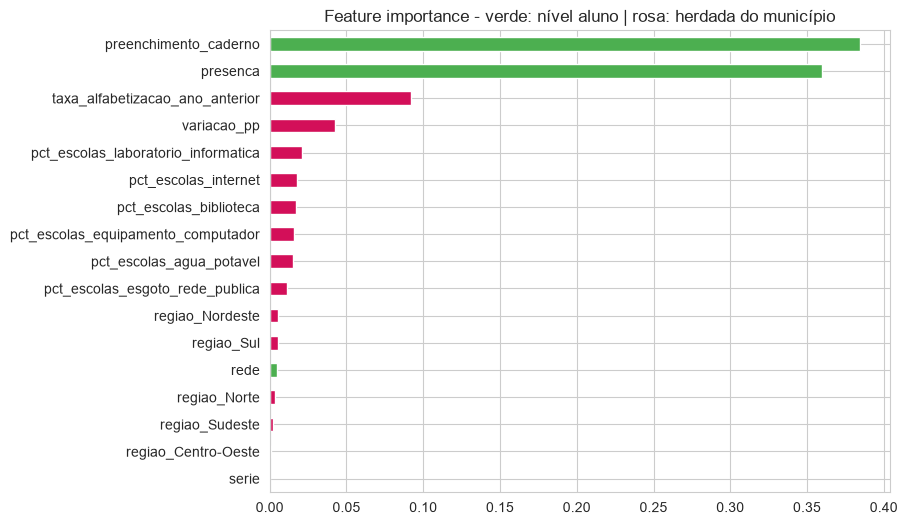

In [14]:
importancias = pd.Series(modelo_diagnostico.feature_importances_, index=todas_features).sort_values(ascending=False)

print("Importância de cada feature:")
print(importancias)

peso_aluno_pct = importancias[features_aluno].sum() * 100
peso_municipio_pct = importancias[features_municipio].sum() * 100
peso_regiao_pct = importancias[features_regiao].sum() * 100

print(f"\nPeso somado das features de ALUNO ({features_aluno}): {peso_aluno_pct:.1f}%")
print(f"Peso somado das features de MUNICÍPIO, incluindo região: {peso_municipio_pct:.1f}%")
print(f"  ...das quais, só a REGIÃO ({features_regiao}): {peso_regiao_pct:.1f}%")

plt.figure(figsize=(8, 6))
cores = ["#4CAF50" if f in features_aluno else "#D30F59" for f in importancias.index]
importancias.plot(kind="barh", color=cores)
plt.title("Feature importance - verde: nível aluno | rosa: herdada do município")
plt.gca().invert_yaxis()
plt.show()

*(anotar aqui depois de rodar: qual grupo pesou mais? Se o peso de município for muito maior que o de aluno, isso é um forte indício de que a granularidade real do problema é município, não aluno - decisão a documentar em `reports/decisoes.md` antes de fechar o Dia 3)*

## 9. Verificação de leakage estrutural — `presenca` e `preenchimento_caderno`

No diagnóstico da Seção 8, `presenca` e `preenchimento_caderno` apareceram como as duas features de maior peso, de longe (juntas, mais de 70% da importância nas primeiras rodadas). Antes de aceitar isso como sinal real de que "estar presente"/"preencher o caderno" influencia a alfabetização, preciso descartar uma explicação bem mais chata: será que `alfabetizado` já é definido de forma mecânica a partir dessas colunas — por exemplo, todo aluno ausente já entrando automaticamente como "não alfabetizado", mesmo sem ter feito a prova?

Se for esse o caso, é o mesmo tipo de problema que encontrei com `proficiencia` no Dia 1 (Seção 6 do notebook `00_verificacao_leakage.ipynb`), só que dessa vez eu não tinha percebido de cara, porque essas duas colunas pareciam só metadado da aplicação da prova, não uma variável de resultado. Faço a mesma lógica de checagem aqui: olhar a taxa de alfabetização por categoria e ver se alguma bate em 0% ou 100% (sinal de regra mecânica) em vez de só "correlacionada".

In [15]:
print("Categorias de presença:")
print(base["presenca_descricao"].value_counts(dropna=False))

print("\nCategorias de preenchimento do caderno:")
print(base["preenchimento_caderno_descricao"].value_counts(dropna=False))

Categorias de presença:
presenca_descricao
Presente    3355846
Ausente      512153
Name: count, dtype: int64

Categorias de preenchimento do caderno:
preenchimento_caderno_descricao
Prova preenchida        3354661
Prova não preenchida     513338
Name: count, dtype: int64


In [16]:
# tabela cruzada em % por linha - se alguma categoria aparecer com 0% ou
# 100% de alfabetizado=1, é sinal de regra mecânica (leakage estrutural),
# não só correlação
print("Tabela cruzada presença x alfabetizado (% por categoria de presença):")
display(pd.crosstab(base["presenca_descricao"], base["alfabetizado"], normalize="index").mul(100).round(2))

print("\nTabela cruzada preenchimento_caderno x alfabetizado (% por categoria):")
display(pd.crosstab(base["preenchimento_caderno_descricao"], base["alfabetizado"], normalize="index").mul(100).round(2))

# também preciso saber o volume - se a categoria "problemática" for muito
# pequena, o impacto de excluir essas linhas do escopo é pequeno; se for
# grande, a decisão pesa mais
print("\nVolume de linhas por categoria de presença:")
print(base["presenca_descricao"].value_counts())
print("\nVolume de linhas por categoria de preenchimento_caderno:")
print(base["preenchimento_caderno_descricao"].value_counts())

Tabela cruzada presença x alfabetizado (% por categoria de presença):


alfabetizado,0,1
presenca_descricao,,
Ausente,100.00,0.00
Presente,40.86,59.14



Tabela cruzada preenchimento_caderno x alfabetizado (% por categoria):


alfabetizado,0,1
preenchimento_caderno_descricao,,
Prova não preenchida,100.00,0.00
Prova preenchida,40.84,59.16



Volume de linhas por categoria de presença:
presenca_descricao
Presente    3355846
Ausente      512153
Name: count, dtype: int64

Volume de linhas por categoria de preenchimento_caderno:
preenchimento_caderno_descricao
Prova preenchida        3354661
Prova não preenchida     513338
Name: count, dtype: int64


*(anotar aqui depois de rodar: alguma categoria de `presenca` ou `preenchimento_caderno` bateu em 0% ou 100% de alfabetização? Se sim, é leakage estrutural confirmado — decisão a tomar: excluir essas duas colunas do modelo final, ou restringir o escopo do modelo a alunos presentes/com caderno preenchido e documentar esse recorte explicitamente no README e em `reports/decisoes.md`. Se as taxas forem altas mas não 0%/100%, é correlação real e as colunas podem continuar, com essa ressalva documentada.)*

### 9.1 Deep dive: `presenca` e `preenchimento_caderno` são a mesma informação, e têm padrão territorial?

Confirmado o leakage estrutural (100% dos ausentes/não-preenchidos são `alfabetizado=0`), quero entender melhor essas duas colunas antes de decidir o tratamento (pendência 1 em `doc/pendencias.md`), porque, tirando elas, `serie` teve importância 0,0 no diagnóstico da Seção 8 e `rede` tem peso marginal baixo (Seção 13) — ou seja, são praticamente as duas únicas variáveis genuinamente de nível aluno que mostraram algum sinal até agora. Duas perguntas:

1. `presenca="Ausente"` e `preenchimento_caderno="Prova não preenchida"` são basicamente a mesma coisa (redundantes), ou existem alunos presentes que não preencheram, e vice-versa?
2. A não-participação (ausência/não-preenchimento) tem um padrão territorial próprio? Isso não resolve o problema de leakage pro modelo de alfabetização, mas pode ser um achado à parte, relevante pra política pública (município/região com mais ausência no dia da prova é, em si, um sinal de risco educacional).

In [17]:
# pergunta 1: as duas colunas são redundantes entre si?
print("Presença x preenchimento do caderno (contagem de linhas por combinação):")
display(pd.crosstab(base["presenca_descricao"], base["preenchimento_caderno_descricao"]))

# qual fração da base é afetada pela regra mecânica (ausente OU não preenchido)?
afetados_leakage = (
    (base["presenca_descricao"] == "Ausente")
    | (base["preenchimento_caderno_descricao"] == "Prova não preenchida")
)
print(f"\nLinhas afetadas pela regra mecânica (ausente ou não preenchido): {afetados_leakage.sum():,} ({afetados_leakage.mean() * 100:.2f}% da base)")

Presença x preenchimento do caderno (contagem de linhas por combinação):


preenchimento_caderno_descricao,Prova não preenchida,Prova preenchida
presenca_descricao,,
Ausente,512153,0
Presente,1185,3354661



Linhas afetadas pela regra mecânica (ausente ou não preenchido): 513,338 (13.27% da base)


In [18]:
# pergunta 2: a não-participação tem padrão territorial? (achado à parte,
# não é sobre o modelo de alfabetização - é sobre política pública)
base_temp = base.assign(nao_participou=afetados_leakage.astype(int))

print("Taxa de não-participação (ausente ou não preenchido) por região (%):")
print(
    base_temp.groupby("nome_regiao")["nao_participou"].mean().mul(100).round(2).sort_values(ascending=False)
)

print("\nTaxa de não-participação por rede de ensino (%):")
print(
    base_temp.groupby("rede_descricao")["nao_participou"].mean().mul(100).round(2).sort_values(ascending=False)
)

Taxa de não-participação (ausente ou não preenchido) por região (%):
nome_regiao
Sul             18.12
Norte           17.98
Sudeste         12.55
Centro-Oeste    11.75
Nordeste         9.16
Name: nao_participou, dtype: float64

Taxa de não-participação por rede de ensino (%):
rede_descricao
Estadual     14.42
Municipal    13.13
Privada       4.00
Name: nao_participou, dtype: float64


**Resultado (rodado em 2026-09-06):**

Tabela cruzada `presenca` x `preenchimento_caderno` (contagem de linhas):

| | Prova não preenchida | Prova preenchida |
|---|---|---|
| Ausente | 512.153 | 0 |
| Presente | 1.185 | 3.354.661 |

**As duas colunas são praticamente redundantes.** Todo aluno ausente (512.153) tem prova não preenchida, sem exceção — faz sentido, quem não compareceu não tem como preencher nada. A única divergência real são 1.185 alunos presentes que mesmo assim não preencheram a prova (0,03% da base, insignificante em volume). Ou seja, `preenchimento_caderno` não traz quase nenhuma informação que `presenca` já não contém — são, na prática, a mesma variável.

**Volume total afetado pela regra mecânica** (ausente OU não preenchido): 513.338 linhas, **13,27% da base inteira**. Não é um recorte pequeno — é uma fatia relevante, mas ainda deixa ~86,7% da base (~3,35 milhões de alunos) disponível caso eu decida restringir o escopo a quem participou de fato (opção (b) da pendência 1).

**A não-participação tem padrão territorial próprio, e ele NÃO repete o padrão de alfabetização:**

Por região: Sul 18,12% > Norte 17,98% > Sudeste 12,55% > Centro-Oeste 11,75% > Nordeste 9,16%.
Por rede: Estadual 14,42% > Municipal 13,13% > Privada 4,00%.

Isso é um achado interessante à parte: na taxa de *alfabetização* (Seção 4), a ordem era Centro-Oeste > Sudeste > Sul > Nordeste > Norte — ou seja, Norte era a região com pior alfabetização, mas aqui o Sul (região com boa alfabetização) tem a MAIOR taxa de não-participação, e o Nordeste (alfabetização mediana-baixa) tem a MENOR. Não-participação e alfabetização não seguem o mesmo mapa geográfico — são fenômenos distintos, o que reforça que não dá pra tratar ausência como "só mais um sintoma de baixo desempenho regional". Por rede, o padrão é mais intuitivo: rede privada tem participação bem mais garantida (4% de não-participação vs. 13-14% nas redes públicas), plausivelmente ligado a acompanhamento familiar/logística escolar.

**Registrei em `reports/decisoes.md`** como achado à parte, candidato a virar uma das perguntas de negócio do Dia 6 (mapa de não-participação como indicador complementar de risco educacional). Isso não fecha a pendência 1 (tratamento de `presenca`/`preenchimento_caderno` no modelo de alfabetização), que segue em aberto — mas confirma que, se eu excluir as duas por leakage, não perco muita informação excluindo `preenchimento_caderno` especificamente (ela é redundante com `presenca`).

## 10. Evidência empírica para a estratégia de split treino/teste

Já expliquei o conceito de `GroupShuffleSplit`/`GroupKFold`: garantir que todas as linhas de um mesmo `id_municipio` fiquem inteiramente no treino OU inteiramente no teste, nunca divididas entre os dois, pra não inflar a validação com municípios que o modelo "já viu" através de outros alunos do mesmo lugar.

Em vez de só confiar no argumento teórico, quero medir isso na prática: comparo um split aleatório comum (`train_test_split`, ignorando município) com um split por grupo (`GroupShuffleSplit`, respeitando município), e vejo quantos municípios do conjunto de teste também aparecem no treino em cada caso. Se a sobreposição do split aleatório for alta, confirma que o `GroupKFold` é necessário aqui — não é só cautela teórica.

In [19]:
from sklearn.model_selection import GroupShuffleSplit

amostra_split = base.sample(n=300_000, random_state=42)

# split aleatório comum, ignorando o município - é o que eu faria "por padrão"
# se não tivesse parado pra pensar no problema de granularidade
treino_aleatorio, teste_aleatorio = train_test_split(amostra_split, test_size=0.2, random_state=42)
municipios_treino_aleatorio = set(treino_aleatorio["id_municipio"])
municipios_teste_aleatorio = set(teste_aleatorio["id_municipio"])
sobreposicao_aleatoria = (
    len(municipios_teste_aleatorio & municipios_treino_aleatorio) / len(municipios_teste_aleatorio) * 100
)

# split por grupo, respeitando município - nenhum município deveria aparecer nos dois lados
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_treino, idx_teste = next(splitter.split(amostra_split, groups=amostra_split["id_municipio"]))
municipios_treino_grupo = set(amostra_split.iloc[idx_treino]["id_municipio"])
municipios_teste_grupo = set(amostra_split.iloc[idx_teste]["id_municipio"])
sobreposicao_grupo = len(municipios_teste_grupo & municipios_treino_grupo) / len(municipios_teste_grupo) * 100

print(f"Split aleatório comum: {sobreposicao_aleatoria:.1f}% dos municípios do teste também aparecem no treino")
print(f"Split por grupo (GroupShuffleSplit): {sobreposicao_grupo:.1f}% dos municípios do teste também aparecem no treino")

Split aleatório comum: 99.5% dos municípios do teste também aparecem no treino
Split por grupo (GroupShuffleSplit): 0.0% dos municípios do teste também aparecem no treino


**Resultado (rodado em 2026-09-06):** Split aleatório comum: **99,5%** dos municípios do teste também aparecem no treino. Split por grupo (`GroupShuffleSplit` por `id_municipio`): **0,0%**.

Confirma o esperado: com ~700 alunos por município em média (Seção 7), um split aleatório comum praticamente garante que o modelo já "viu" o município no treino antes de ser avaliado nele no teste — isso infla artificialmente qualquer métrica de validação, porque parte do que pareceria "generalização" é só o modelo reconhecendo um município que já processou.

**Decisão:** usar `GroupKFold`/`GroupShuffleSplit` por `id_municipio` na validação do Dia 3, nunca um split ou `StratifiedKFold` comum.

## 11. Evidência para a escolha de métrica de avaliação

Como o desbalanceamento é leve (Seção 2), a acurácia não fica tão distorcida quanto ficaria num problema muito desbalanceado, mas mesmo assim quero medir o quão "fácil" seria enganar a acurácia com um classificador bobo — um que sempre prevê a classe majoritária, sem aprender nada. Isso me dá um piso de comparação concreto: qualquer modelo real precisa superar esse número por uma margem clara pra eu poder dizer que ele está aprendendo alguma coisa.

In [20]:
from sklearn.metrics import accuracy_score

classe_majoritaria = base["alfabetizado"].astype(int).mode()[0]
baseline_previsoes = pd.Series(classe_majoritaria, index=base.index)
acuracia_baseline = accuracy_score(base["alfabetizado"].astype(int), baseline_previsoes)

print(f"Classe majoritária: {classe_majoritaria}")
print(f"Acurácia de um classificador bobo (sempre prevê a classe majoritária): {acuracia_baseline * 100:.2f}%")

Classe majoritária: 1
Acurácia de um classificador bobo (sempre prevê a classe majoritária): 51.31%


*(anotar aqui: a acurácia baseline ficou perto de 51% (como esperado pelo item 1)? Isso reforça que vou reportar acurácia só como referência, e usar AUC-ROC (mede separação entre as classes) e F1 (equilibra precisão e recall) como métricas principais no Dia 4 — especialmente porque este é um problema de política pública, onde deixar de identificar um aluno em risco (falso negativo da classe "não alfabetizado") tende a ser mais custoso do que o contrário. Decisão: métrica principal = AUC-ROC + F1 da classe "não alfabetizado", acurácia reportada como complemento.)*

## 12. Evidência para a estratégia de imputação de nulos

Já vi na Seção 1 que as colunas de infraestrutura/metas têm nulos onde o município não tem correspondência na fonte externa (não é erro, é ausência real de dado, conforme o handoff). Antes de decidir só imputar com a mediana, quero checar uma coisa: a ausência desse dado está associada a uma taxa de alfabetização diferente? Se estiver, a própria ausência é informação relevante (não é "aleatória"), e faz mais sentido criar uma flag binária de "tinha dado ou não", além de imputar, em vez de só preencher o buraco e seguir em frente.

In [21]:
# qualquer uma das colunas de infraestrutura serve como indicador de "tinha
# dado ou não", já que elas vêm todas juntas do mesmo LEFT JOIN
coluna_infra_referencia = "pct_escolas_internet"

tem_dado_infra = base[coluna_infra_referencia].notna()

taxa_com_dado = (base.loc[tem_dado_infra, "alfabetizado"].astype(int) == 1).mean() * 100
taxa_sem_dado = (base.loc[~tem_dado_infra, "alfabetizado"].astype(int) == 1).mean() * 100

print(f"Alunos com dado de infraestrutura do município: {tem_dado_infra.sum():,} ({tem_dado_infra.mean() * 100:.1f}%)")
print(f"Taxa de alfabetização (com dado de infraestrutura): {taxa_com_dado:.2f}%")
print(f"\nAlunos sem dado de infraestrutura do município: {(~tem_dado_infra).sum():,} ({(~tem_dado_infra).mean() * 100:.1f}%)")
print(f"Taxa de alfabetização (sem dado de infraestrutura): {taxa_sem_dado:.2f}%")

Alunos com dado de infraestrutura do município: 3,864,790 (99.9%)
Taxa de alfabetização (com dado de infraestrutura): 51.35%

Alunos sem dado de infraestrutura do município: 3,209 (0.1%)
Taxa de alfabetização (sem dado de infraestrutura): 0.00%


**Resultado (rodado em 2026-09-06):** Alunos com dado de infraestrutura: **3.864.790 (99,9%)**, taxa de alfabetização **51,35%**. Alunos sem dado: **3.209 (0,1%)**, taxa de alfabetização **0,00%**.

A diferença é extrema (51,35% vs. 0,00%), não parecida — ou seja, a ausência do dado **não é aleatória**, está fortemente associada ao alvo. Isso levanta a suspeita de que esse pequeno grupo possa se sobrepor ao grupo de leakage estrutural (presença/preenchimento, Achado 6), mas a escala não bate exatamente (3.209 é ~160x menor que os 513.338 afetados pela regra de ausência) — na melhor hipótese seria um subconjunto pequeno dele, não o mesmo fenômeno (checagem direta ainda pendente, pendência 2).

**Decisão provisória:** não tratar como nulo "aleatório" — usar `SimpleImputer` com mediana dentro do `Pipeline`, mas também criar uma flag binária `_dado_ausente` pra preservar essa informação, em vez de escondê-la só na imputação. Fica sujeita à confirmação da pendência 2.

## 13. Correlação vs. causalidade — `rede` de ensino e infraestrutura escolar

Voltando à Seção 4: a rede privada tem taxa de alfabetização de 64%, contra ~51-53% nas redes públicas. É tentador ler isso como "estudar em escola privada causa alfabetização", mas isso é o tipo de conclusão que preciso desconfiar antes de colocar no relatório final. Municípios com mais escolas privadas tendem a ser, em geral, municípios mais ricos e com infraestrutura escolar melhor **no geral** (inclusive nas escolas públicas de lá) — ou seja, `rede` pode estar só "pegando carona" numa característica do município (infraestrutura/renda), sem ser ela mesma a causa.

Quero comparar a taxa de alfabetização por rede (já calculada) com a média das colunas de infraestrutura, agrupada pela mesma `rede_descricao`. Se os municípios com mais alunos de rede privada também tiverem infraestrutura média mais alta, isso é evidência de confusão (*confounding*): a variável realmente explicativa pode ser a condição socioeconômica do município, e `rede` só reflete essa condição de forma indireta.

**Limitação importante para interpretar esse resultado:** as colunas de infraestrutura (`pct_escolas_*`) são uma média de **todas** as escolas do município (públicas e privadas misturadas, ver handoff seção 8.7) — não é a infraestrutura da escola específica de cada aluno. Então, mesmo essa comparação é uma correlação no nível do município (ecológica), não uma comparação direta "infraestrutura da escola privada do aluno X" vs. "infraestrutura da escola pública do aluno Y". Isso reforça, mais uma vez, a limitação já documentada de não termos o dado de infraestrutura por escola (`id_escola`), só por município.

In [22]:
# tabela consolidada: taxa de alfabetização x médias de infraestrutura do
# município, por rede de ensino - é a comparação que testa a hipótese de
# confounding (rede "pegando carona" na infraestrutura do município)
tabela_rede_infra = base.groupby("rede_descricao").agg(
    taxa_alfabetizacao=("alfabetizado", lambda s: (s.astype(int) == 1).mean() * 100),
    agua_potavel=("pct_escolas_agua_potavel", "mean"),
    internet=("pct_escolas_internet", "mean"),
    equipamento_computador=("pct_escolas_equipamento_computador", "mean"),
    biblioteca=("pct_escolas_biblioteca", "mean"),
    laboratorio_informatica=("pct_escolas_laboratorio_informatica", "mean"),
    esgoto_rede_publica=("pct_escolas_esgoto_rede_publica", "mean"),
).sort_values("taxa_alfabetizacao", ascending=False)

print("Taxa de alfabetização e infraestrutura média do município, por rede de ensino:")
display(tabela_rede_infra.round(2))

Taxa de alfabetização e infraestrutura média do município, por rede de ensino:


,taxa_alfabetizacao,agua_potavel,internet,equipamento_computador,biblioteca,laboratorio_informatica,esgoto_rede_publica
rede_descricao,,,,,,,
Privada,64.00,100.00,100.00,98.40,53.20,40.30,50.00
Estadual,53.15,98.53,95.71,92.39,44.57,37.59,74.77
Municipal,51.07,97.55,95.24,91.08,43.18,32.66,61.48


## 14. Conclusões e decisões para a modelagem

*(cada item é numerado pra facilitar referência nas nossas conversas: "responde o item 7", por exemplo — atualizado em 2026-09-06)*

1. **Desbalanceamento de classes:** leve (51,31% classe 1, 48,69% classe 0) — não precisa de balanceamento artificial. **Decisão:** reportar AUC-ROC + F1 no Dia 4, acurácia só como referência (piso de um classificador bobo: 51,31%, Seção 11).
2. **Infraestrutura escolar parece relevante (isoladamente)?** Mostra diferença visual nos boxplots (Seção 3), mas teve importância individual baixa no diagnóstico de árvore (Seção 8) — provavelmente porque é dado agregado por município (não por escola), o que dilui o sinal real (limitação documentada em `decisoes.md`, Achado 2). A tabela de correlação simples da Seção 6 complementa essa leitura.
3. **Rede de ensino faz diferença? É correlação ou pode ser confundida com infraestrutura/renda do município?** Diferença real (Privada 64% vs. Estadual 53,15% vs. Municipal 51,07%), mas majoritariamente confundida: em 5 das 6 colunas de infraestrutura, a ordem Privada > Estadual > Municipal é idêntica à da taxa de alfabetização (Seção 13). Exceção: `esgoto_rede_publica` inverte esse padrão. **Decisão:** manter `rede` como feature, mas documentar a relação como majoritariamente correlacional/confundida com a condição do município, não causal.
4. **Padrão regional existe, e teve peso no diagnóstico de feature importance (Seção 8) depois de incluído?** Existe e é grande na visão bivariada (Centro-Oeste 54,71% até Norte 41,77%, ~13 p.p. de diferença, Seção 4). O peso exato da região dentro do diagnóstico de árvore (depois de eu ter adicionado os dummies de região ao código da Seção 8) ainda não foi confirmado com uma nova rodada — falta rodar a Seção 8 atualizada e conferir `peso_regiao_pct`.
5. **Ano muda o padrão?** Não de forma relevante (50,21% em 2023, 52,21% em 2024, ~2 p.p.). **Decisão:** manter os dois anos juntos na mesma base, sem necessidade de modelar separadamente.
6. **Multicolinearidade entre features de infraestrutura, e correlação de cada variável com o alvo?** Multicolinearidade entre infraestruturas é baixa (Spearman máx. 0,43). A tabela de correlação de cada variável (codificada) com `alfabetizado` foi adicionada na Seção 6 — falta rodar e revisar o resultado.
7. **`presenca`/`preenchimento_caderno` têm leakage estrutural? Qual o tratamento decidido?** Leakage estrutural confirmado (Seção 9): 100% dos ausentes/não-preenchidos são `alfabetizado=0` — 13,27% da base (Seção 9.1). As duas colunas são quase redundantes entre si (só 1.185 exceções). **Em aberto** (pendência 1) — ainda preciso de mais informação antes de decidir entre excluir, restringir escopo a presentes, ou manter como parte da definição oficial do indicador. Continua relevante mesmo depois do pivô pra escola (item 10), porque entra no cálculo do numerador/denominador do novo alvo por escola.
8. **`taxa_alfabetizacao_ano_anterior`/`variacao_pp` são seguras de usar?** **Adiado para o Dia 3** (pendência 3) — não é leakage no sentido de vazar o próprio resultado, mas é uma agregação defasada do próprio fenômeno-alvo, com ressalvas documentadas em `decisoes.md` (Achado 7).
9. **Granularidade real do problema (aluno vs. município), com base nas seções 7, 8 e 9:** **Decidido — mas não como aluno nem como município.** A evidência confirmou que praticamente não sobra sinal genuíno de aluno depois de tratar o item 7 (leakage), com `serie` de importância zero e `rede` fraca e parcialmente confundida (item 3) — mas, em vez de recuar para "município" (que mistura escolas muito diferentes entre si, Seção 13), a decisão foi pivotar para a granularidade **escola** (ver item 10).
10. **Se a granularidade migrar, o que muda no target e nas perguntas de negócio?** **Decidido em 2026-09-06: remodelagem do problema para o nível de ESCOLA (Opção C).** Motivo: a tabela Bronze `br_inep_censo_escolar.escola` (já ingerida, 455 colunas, granularidade por escola) tem uma base de features muito mais rica que `alunos` — inclusive demografia de matrícula (sexo, raça, faixa etária, zona, turno) que não existe a nível aluno — e a escola é a unidade sobre a qual políticas públicas conseguem atuar diretamente (mais operacionalizável que "o aluno individual", mais granular que "o município"). A nova variável-alvo passa a ser um indicador de alfabetização agregado por `(id_escola, ano)` — percentual de alunos alfabetizados, com um corte a definir para "escola boa"/"escola ruim" (pendência 11, ainda não decidida). Limitação assumida: a tabela `escola` só existe para `ano=2024`; decidido aplicar esses dados também aos alunos de 2023, espelhando a premissa já usada na Fase 2 pra infraestrutura agregada por município ("infraestrutura não muda muito ano a ano"). **Esta EDA (Opção A, nível aluno) não é descartada** — é exatamente a evidência que fundamenta o pivô, e continua sendo o entregável do Dia 2. Próximos passos abertos por essa decisão: definir o alvo por escola (pendência 11), checar a interseção `alunos`↔`escola` via `id_escola` (pendência 12), selecionar/tratar as 455 colunas (pendência 13), reaplicar a checagem de leakage na nova granularidade (pendência 14), e replanejar o cronograma dos Dias 3-7 (pendência 15). Detalhes completos em `reports/decisoes.md`, seção "Decisão de arquitetura".
11. **Estratégia de split treino/teste:** **Decidido.** `GroupKFold`/`GroupShuffleSplit` por `id_municipio` — split aleatório comum deixou 99,5% dos municípios do teste também no treino, contra 0,0% no split por grupo (Seção 10). Continua valendo com o pivô pra escola (o grupo, nesse caso, provavelmente também deveria considerar município, já que escolas do mesmo município tendem a compartilhar contexto).
12. **Métrica de avaliação para o Dia 4:** **Decidido.** AUC-ROC + F1 da classe "não alfabetizado" como métricas principais, acurácia como complemento (Seção 11, e item 1 acima).
13. **Estratégia de imputação de nulos para o Dia 3:** Só 0,1% da base (3.209 alunos) não tem dado de infraestrutura, e esse grupo tem taxa de alfabetização de exatamente 0% (Seção 12). **Correção:** eu tinha especulado que esse grupo poderia coincidir com o grupo de leakage do item 7, mas a escala não bate (3.209 é muito menor que os 513.338 do item 7) — na melhor hipótese, seria um subconjunto pequeno dele, não o mesmo fenômeno. Ainda precisa de uma checagem direta (pendência 2) antes de fechar. Estratégia ainda não fechada — provavelmente `SimpleImputer` com mediana dentro do `Pipeline`, com ou sem flag de ausência a depender de como a pendência 2 se resolver.

**Resultado (rodado em 2026-09-06):**

| Rede | Taxa alfabetização | Água potável | Internet | Equip. computador | Biblioteca | Lab. informática | Esgoto rede pública |
|---|---|---|---|---|---|---|---|
| Privada | 64,00% | 100,00% | 100,00% | 98,40% | 53,20% | 40,30% | 50,00% |
| Estadual | 53,15% | 98,53% | 95,71% | 92,39% | 44,57% | 37,59% | 74,77% |
| Municipal | 51,07% | 97,55% | 95,24% | 91,08% | 43,18% | 32,66% | 61,48% |

**Confirma a suspeita de confounding, mas com uma exceção importante.** Em 5 das 6 colunas de infraestrutura (água potável, internet, equipamento de computador, biblioteca, laboratório de informática), a ordem Privada > Estadual > Municipal é exatamente a mesma ordem da taxa de alfabetização — evidência de que boa parte da associação entre `rede` e `alfabetizado` reflete a condição geral de infraestrutura (e provavelmente socioeconômica) do município onde o aluno estuda, não um efeito isolado de "estudar em escola privada".

A exceção é `esgoto_rede_publica`, que **inverte** completamente o padrão (Estadual 74,77% > Municipal 61,48% > Privada 50,00%) — mostra que "infraestrutura" não é um eixo único de "município rico vs. pobre"; conectividade à rede pública de esgoto provavelmente depende mais de zoneamento urbano/histórico de saneamento do que da condição socioeconômica geral do município (hipótese, não confirmada com os dados que tenho).

**Decisão:** `rede` continua como feature (a associação é real e relevante pra descrever o fenômeno), mas a interpretação final deixa explícito que essa relação é majoritariamente correlacional/confundida com a condição do município — não um efeito causal isolado de "estudar em escola privada". O enriquecimento com o Atlas do Desenvolvimento Humano (IDH-M/renda por município, pendência 7) é o que vai permitir separar melhor esses efeitos. Detalhes completos e a discussão da limitação ecológica (infra é média do município, não da escola do aluno) estão em `reports/decisoes.md`, Achado 3.